In [30]:
import pandas as pd
import os

df = pd.read_excel(r"C:\Users\LENOVO\Downloads\Dataset for Data Analytics.xlsx")

print("First 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nDataset Information")
print(df.info())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values Before Cleaning")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df = df.drop_duplicates()

df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["ItemsInCart"] = pd.to_numeric(df["ItemsInCart"], errors="coerce")
df["TotalPrice"] = pd.to_numeric(df["TotalPrice"], errors="coerce")

text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()

for col in ["Product", "PaymentMethod", "OrderStatus", "ReferralSource"]:
    df[col] = df[col].str.title()

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

print("\nUpdated Data Types")
print(df.dtypes)

print("\nCleaned Dataset Preview")
print(df.head())

output_path = r"C:\Users\LENOVO\Downloads\Cleaned_Dataset_v2.xlsx"

df.to_excel(output_path, index=False)

print("\nDataset cleaned successfully!")
print("File Saved:", os.path.exists(output_path))
print("Saved Location:", output_path)

First 5 Rows
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2

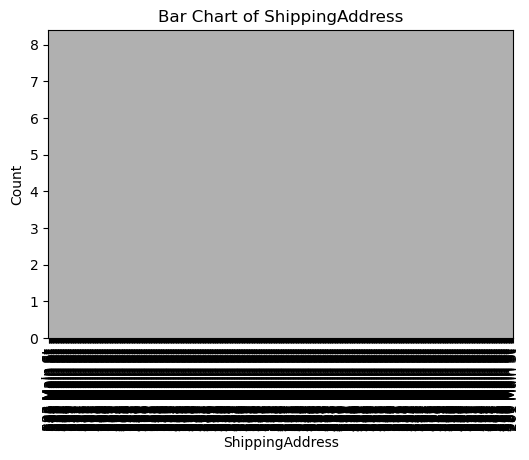

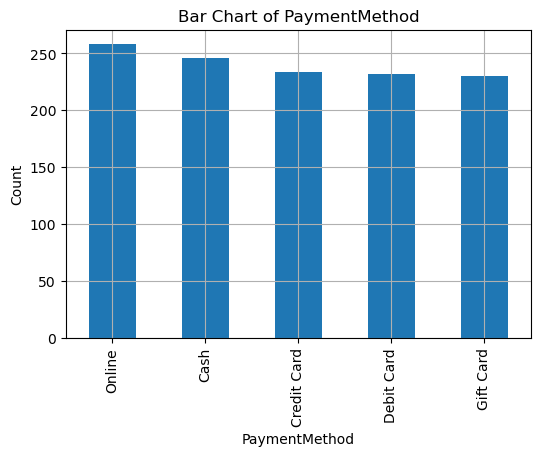

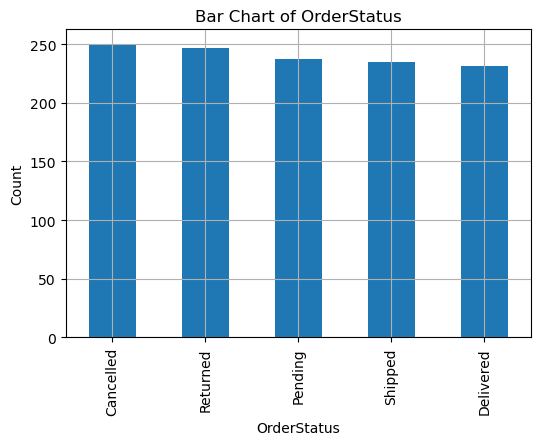